#### Import core Python libraries

rasterio: Used to read and manage geospatial raster data (GeoTIFF files)
numpy: Provides numerical operations for analyzing NDVI pixel values
matplotlib.pylot: Used to visualize the NDVI raster as an image

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

This cell defines the file path to the exported NDVI GeoTIFF and opens it using rasterio

- ndvi_path specifies the location of the NDVI raster
- `rasterio.open()` opens the file in read mode
- src contains spatial metadata such as:
  - Coordinate Reference System (CRS)
  - Spatial resolution
  - Raster dimensions
  - Geographic bounds

In [36]:
# computed NDVI using Google Earth Engine

#nyc, ny 
ndvi_path_nyc = "../data/raw/ndvi/nyc_ndvi_2023.tif"
src_nyc = rasterio.open(ndvi_path_nyc)
src_nyc 

#maricopa county, az
ndvi_path_mc = "../data/raw/ndvi/maricopa_ndvi_2023.tif" 
src_mc = rasterio.open(ndvi_path_mc)
src_mc 

#chicago, il (cook county)
ndvi_path_ch = "../data/raw/ndvi/cook_county_ndvi_2023.tif"
src_ch = rasterio.open(ndvi_path_ch)
src_ch 

<open DatasetReader name='../data/raw/ndvi/cook_county_ndvi_2023.tif' mode='r'>

### Inspect Raster Spatial Metadata

This cell prints spatial properties of the NDVI raster to verify its integrity before analysis

In [38]:
# Print spatial reference system
print("CRS NYC:", src_nyc.crs)
print("CRS Maricopa County (MC):", src_mc.crs)
print("CRS Chicago (CH):", src_ch.crs)

# Print pixel resolution 
print("\nResolution (meters) NYC:", src_nyc.res)
print("Resolution (meters) MC:", src_mc.res)
print("Resolution (meters) CH:", src_ch.res)

# Print geographic bounding box of raster
print("\nBounds NYC:", src_nyc.bounds)
print("Bounds MC:", src_mc.bounds)
print("Bounds CH:", src_ch.bounds)

# Print raster dimensions (columns x rows)
print("\nWidth x Height NYC:", src_nyc.width, "x", src_nyc.height)
print("Width x Height MC:", src_mc.width, "x", src_mc.height)
print("Width x Height CH:", src_ch.width, "x", src_ch.height)

CRS NYC: EPSG:4326
CRS Maricopa County (MC): EPSG:4326
CRS Chicago (CH): EPSG:4326

Resolution (meters) NYC: (8.983152841195215e-05, 8.983152841195215e-05)
Resolution (meters) MC: (8.983152841195215e-05, 8.983152841195215e-05)
Resolution (meters) CH: (8.983152841195215e-05, 8.983152841195215e-05)

Bounds NYC: BoundingBox(left=-74.25914313021183, bottom=40.47736805019834, right=-73.69994186584742, top=40.91763237094532)
Bounds MC: BoundingBox(left=-113.33451051648484, bottom=32.504909735165995, right=-111.03985395472994, top=34.048215393283336)
Bounds CH: BoundingBox(left=-88.26369874657834, bottom=41.469647113036764, right=-87.11107040552459, top=42.15434302259266)

Width x Height NYC: 6225 x 4901
Width x Height MC: 25544 x 17180
Width x Height CH: 12831 x 7622


### Load NDVI Pixel Values into Memory

This cell reads the NDVI raster band into a NumPy array for analysis

- `src.read(1)` loads raster band
- `ndvi` contains vegetation density values for each pixel
- `ndvi.shape` returns the raster dimensions (rows × columns)

At this point, the NDVI data transitions from a file-based dataset to a numerical array that can be analyzed, visualized, and integrated with machine learning outputs

In [12]:
ndvi_nyc = src_nyc.read(1)  # read the first (and only) band
ndvi_nyc.shape

(4901, 6225)

In [13]:
ndvi_mc = src_mc.read(1) 
ndvi_mc.shape

(17180, 25544)

In [39]:
ndvi_ch = src_ch.read(1) 
ndvi_ch.shape

(7622, 12831)

### Validate NDVI Value Range

This cell computes summary statistics of the NDVI raster:

- **Minimum value**
- **Maximum value**
- **Mean value**

NDVI values should fall between −1 and +1, with:

- Values near 0 -> bare soil or urban surfaces
- Values between 0.2–0.4 -> moderate vegetation
- Values above 0.5 -> dense vegetation

Using `np.nanmin`, `np.nanmax`, and `np.nanmean` ensures missing values do not distort the results

This step confirms the raster contains valid vegetation data before further analysis

In [40]:
print("NYC:") 
print("NDVI min:", np.nanmin(ndvi_nyc))
print("NDVI max:", np.nanmax(ndvi_nyc))
print("NDVI mean:", np.nanmean(ndvi_nyc))

print("\nMaricopa County:") 
print("NDVI min:", np.nanmin(ndvi_mc))
print("NDVI max:", np.nanmax(ndvi_mc))
print("NDVI mean:", np.nanmean(ndvi_mc))

print("\nChicago (Cook County):") 
print("NDVI min:", np.nanmin(ndvi_ch))
print("NDVI max:", np.nanmax(ndvi_ch))
print("NDVI mean:", np.nanmean(ndvi_ch))


NYC:
NDVI min: -0.73657364
NDVI max: 0.8949748
NDVI mean: 0.08315353

Maricopa County:
NDVI min: -0.76427156
NDVI max: 0.89271116
NDVI mean: 0.17774428

Chicago (Cook County):
NDVI min: -0.6578483
NDVI max: 0.9109427
NDVI mean: 0.19582911


### Visualize NDVI (Downsampled for Performance)

The full resolution NDVI raster contains millions of pixels and is too large to render directly therefore:

To improve performance the raster is downsampled by selecting every 10th pixel in both row and column directions. This reduces the number of plotted pixels by 100 times while preserving overall spatial patterns

The downsampled raster is then visualized using a yellow to green colormap:

- Lighter colors indicate low vegetation density
- Darker green areas indicate higher vegetation density

This visualization confirms that the NDVI surface reflects realistic vegetation patterns across NYC.

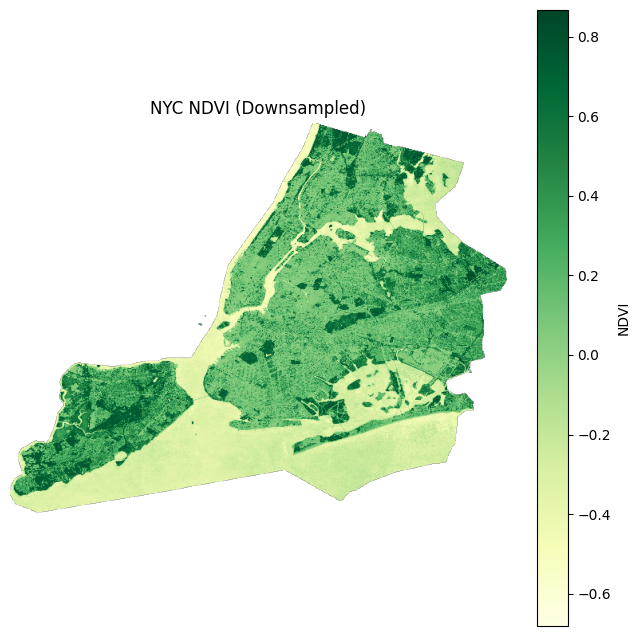

In [16]:
# Downsample for visualization (every 10th pixel)
ndvi_small_nyc = ndvi_nyc[::10, ::10]

plt.figure(figsize=(8, 8))
plt.imshow(ndvi_small_nyc, cmap="YlGn")
plt.colorbar(label="NDVI")
plt.title("NYC NDVI (Downsampled)")
plt.axis("off")
plt.show()

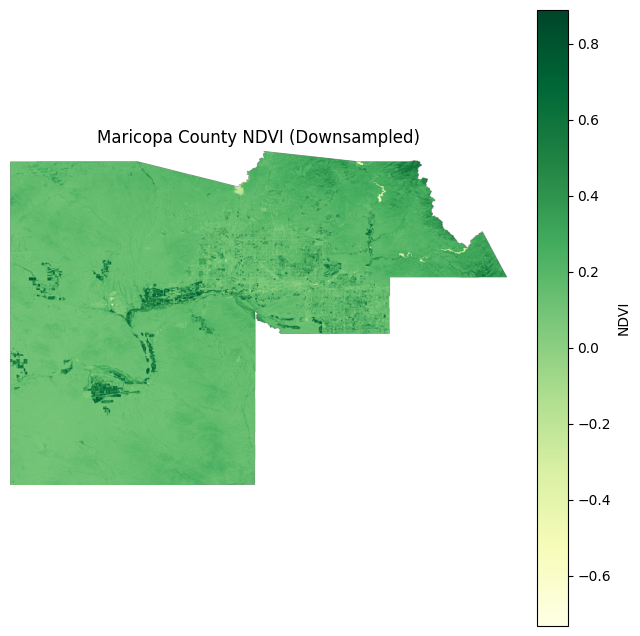

In [17]:
ndvi_small_mc = ndvi_mc[::10, ::10]

plt.figure(figsize=(8, 8))
plt.imshow(ndvi_small_mc, cmap="YlGn")
plt.colorbar(label="NDVI")
plt.title("Maricopa County NDVI (Downsampled)")
plt.axis("off")
plt.show()

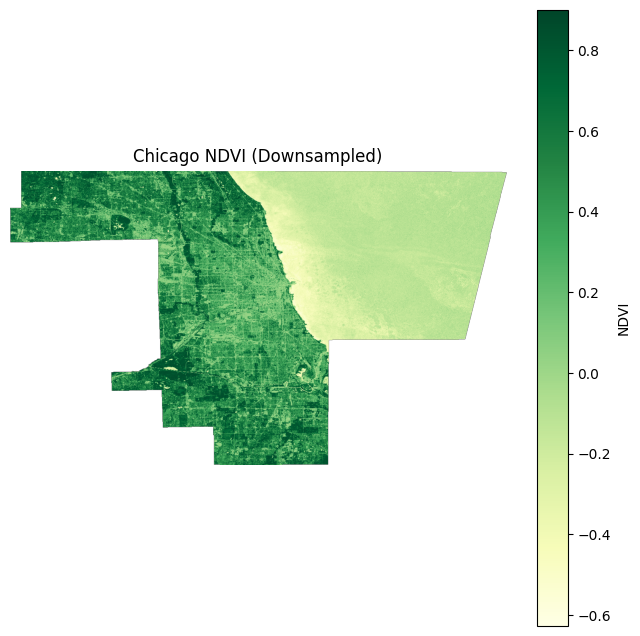

In [42]:
# Downsample for visualization (every 10th pixel)
ndvi_small_ch = ndvi_ch[::10, ::10]

plt.figure(figsize=(8, 8))
plt.imshow(ndvi_small_ch, cmap="YlGn")
plt.colorbar(label="NDVI")
plt.title("Chicago NDVI (Downsampled)")
plt.axis("off")
plt.show()

### Import Vector Spatial Libraries

This cell imports the libraries required for handling vector geospatial data

geopandas: Provides spatial data structures and operations for vector datasets such as boundaries and greenspace polygons

shapely.geometry.box: Allows creation of bounding boxes and geometric objects for spatial filtering or clipping

These tools are used to align administrative boundaries and greenspace polygons with the NDVI raster.

In [43]:
import geopandas as gpd
from shapely.geometry import box

### Load Study Area Boundary

- The boundary file was exported earlier from Google Earth Engine
- `geopandas.read_file()` reads the GeoJSON file and preserves spatial geometry
- The resulting GeoDataFrame contains both attribute information and polygon geometry

Displaying `nyc.head()` confirms the boundary loaded correctly and includes the expected administrative attributes

In [21]:
boundary_path_nyc = "../data/raw/boundaries/nyc_boundary.geojson"
nyc = gpd.read_file(boundary_path_nyc)
nyc.head()

,id,geometry
0,union_result,"MULTIPOLYGON (((-74.04728 40.69052, -74.04701 ..."


In [22]:
boundary_path_mc = "../data/raw/boundaries/maricopa_gaul_level2.geojson"
mc = gpd.read_file(boundary_path_mc)
mc.head()

,id,ADM0_CODE,ADM0_NAME,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,DISP_AREA,EXP2_YEAR,STATUS,STR2_YEAR,Shape_Area,Shape_Leng,geometry
0,00040000000000000a26,259,United States of America,3216,Arizona,28782,Maricopa,NO,3000,Member State,1000,2.3142,8.12006,"POLYGON ((-111.49478 33.99982, -111.50069 33.9..."


In [44]:
boundary_path_ch = "../data/raw/boundaries/cook_county_boundary.geojson"
ch = gpd.read_file(boundary_path_ch)
ch.head()

,id,ALAND,AWATER,CBSAFP,CLASSFP,COUNTYFP,COUNTYNS,CSAFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,LSAD,METDIVFP,MTFCC,NAME,NAMELSAD,STATEFP,geometry
0,000000000000000004f0,2447370818,1786313044,16980,H1,031,01784766,176,A,17031,+41.8942937,-087.6454546,06,16974,G4020,Cook,Cook County,17,"POLYGON ((-88.26366 42.06686, -88.26362 42.066..."


### Verify Coordinate Reference System (CRS) Alignment

This cell compares the CRS of the boundary GeoDataFrame and the NDVI raster

For spatial operations (clipping, overlay, sampling) to work correctly, both raster and vector datasets must share the same CRS

If the CRS values differ the vector data can be reprojected to match the raster in the next step to ensure spatial alignment

In [45]:
print("Boundary CRS NYC:", nyc.crs)
print("Boundary CRS MC:", mc.crs)
print("Boundary CRS CH:", ch.crs)

print("NDVI CRS NYC:", src_nyc.crs)
print("NDVI CRS MC:", src_mc.crs)
print("NDVI CRS CH:", src_ch.crs)

Boundary CRS NYC: EPSG:4326
Boundary CRS MC: EPSG:4326
Boundary CRS CH: EPSG:4326
NDVI CRS NYC: EPSG:4326
NDVI CRS MC: EPSG:4326
NDVI CRS CH: EPSG:4326


### Load OpenStreetMap Greenspace Data

This cell loads the greenspace polygons extracted from OpenStreetMap into a GeoDataFrame

The greenspace dataset represents human accessible natural areas such as parks, gardens, recreational grounds, and wooded areas

Displaying the first few rows confirms that the file loaded correctly and contains valid geometry and attribute information

In [25]:
greenspace_path_nyc = "../data/raw/greenspace/nyc_greenspace.geojson"
greenspace_nyc = gpd.read_file(greenspace_path_nyc)

greenspace_nyc.head()

,element,id,ele,gnis:feature_id,leisure,name,wikidata,name:etymology:wikidata,heritage,heritage:operator,...,name:pt,building:colour,building:material,linear,old_railway_operator,roof:material,roof:shape,protect_class,protected,geometry
0,node,357545993,17,942830,park,Baker Field,Q34804359,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-73.91403 40.87316)
1,node,357573219,7,958459,park,New Springville Park,Q49531247,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-74.17153 40.59649)
2,node,357599530,5,974835,park,Rice Memorial Stadium,NaN,Q473770,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-73.8229 40.84911)
3,node,357607736,23,2042056,park,Lower Forecourt,Q49519855,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-73.90236 40.88927)
4,node,357607739,28,2042057,park,Upper Forecourt,Q34867453,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-73.90208 40.88954)


In [26]:
greenspace_path_mc = "../data/raw/greenspace/maricopa_greenspace.geojson"
greenspace_mc = gpd.read_file(greenspace_path_mc)

greenspace_mc.head()

/Users/saanvikakde/FURI_SP26/venv/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 19132865 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,element,id,ele,gnis:feature_id,leisure,name,wikidata,addr:state,golf,landuse,...,level,toilets,golf:course,construction:amenity,tee,boundary,ownership,not:operator:wikidata,golf:par,geometry
0,node,359241744,231,402,park,Arlington State Wildlife Area,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-112.7735 33.24865)
1,node,359242538,336,1254,park,Berney Park,Q49474501,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-112.03792 33.44116)
2,node,359243879,315,2508,park,Casey Abbott Semi-Regional Park,Q49477174,AZ,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-112.38356 33.37272)
3,node,359249716,412,9196,park,Paradise Park,Q49537521,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-111.8957 33.57365)
4,node,359249858,708,9383,park,Phoenix South Mountain Park,Q49542180,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-112.04765 33.33505)


In [51]:
greenspace_path_ch = "../data/raw/greenspace/chicago_greenspace.geojson"
greenspace_ch = gpd.read_file(greenspace_path_ch)

greenspace_ch.head()

,element,id,ele,gnis:feature_id,leisure,name,wikidata,type,addr:city,addr:housenumber,...,min_height,verge,grass,heritage,heritage:operator,protect_class,protected,protection_title,grassland,geometry
0,node,354097497,181,405519,park,Campbell Park,Q34845956,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.68254 41.87258)
1,node,2274053293,NaN,NaN,park,Six Corner's Parklet,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.74992 41.95311)
2,node,3993096535,NaN,NaN,park,McGee Park,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.67874 41.99584)
3,node,5157207475,NaN,NaN,garden,Garfield Produce Co.,NaN,NaN,Chicago,401,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.71226 41.88875)
4,node,8980777459,NaN,NaN,garden,Sugar from the Sun,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.71771 41.88601)


### Reproject Greenspace to Match NDVI CRS

OpenStreetMap data is typically stored in geographic coordinates (EPSG:4326) while the NDVI raster is often stored in a projected coordinate system (e.g., UTM)

To ensure accurate spatial alignment the greenspace GeoDataFrame is reprojected to match the CRS of the NDVI raster using `.to_crs()`

This step is essential before performing clipping, overlay, or sampling operations

In [28]:
greenspace_nyc = greenspace_nyc.to_crs(src_nyc.crs)
print("Greenspace CRS NYC:", greenspace_nyc.crs)


Greenspace CRS NYC: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [29]:
greenspace_mc = greenspace_mc.to_crs(src_mc.crs)
print("Greenspace CRS MC:", greenspace_mc.crs)

Greenspace CRS MC: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [52]:
greenspace_ch = greenspace_ch.to_crs(src_ch.crs)
print("Greenspace CRS CH:", greenspace_ch.crs)

Greenspace CRS CH: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


### Clip Greenspace to Study Area Boundary

This cell clips the OpenStreetMap greenspace polygons to the Maricopa County boundary

Although the OSM query was restricted to the study region clipping ensures that only features strictly within the administrative boundary are retained

The `.shape` output confirms how many greenspace features remain after clipping

This guarantees spatial consistency before integrating vegetation data with sentiment analysis

In [30]:
greenspace_clipped_nyc = gpd.clip(greenspace_nyc, nyc)
greenspace_clipped_nyc.shape


(29553, 239)

In [31]:
greenspace_clipped_mc = gpd.clip(greenspace_mc, mc)
greenspace_clipped_mc.shape


(19216, 107)

In [53]:
greenspace_clipped_ch = gpd.clip(greenspace_ch, ch)
greenspace_clipped_ch.shape


(10898, 110)

### Visualize Greenspace Within Study Area

This cell overlays the Maricopa County boundary with the clipped OpenStreetMap greenspace polygons

- The county boundary is shown in black
- Greenspace areas are displayed in semi-transparent green

This visualization confirms that:
- Spatial reprojection was successful
- Greenspace features fall within the study area
- The spatial preprocessing pipeline is correctly aligned

This serves as a final validation step before integrating machine learning outputs

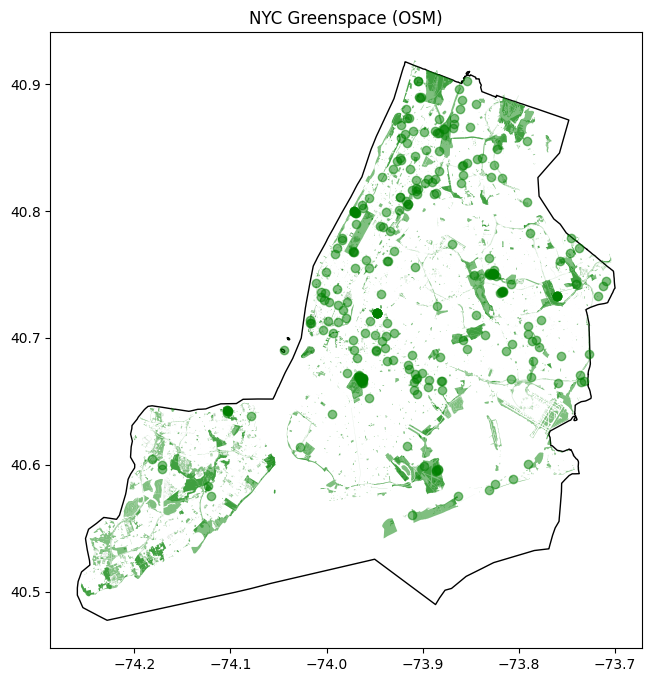

In [33]:
import matplotlib.pyplot as plt

ax = nyc.plot(color="white", edgecolor="black", figsize=(8,8))
greenspace_nyc.plot(ax=ax, color="green", alpha=0.5)

plt.title("NYC Greenspace (OSM)")
plt.show()

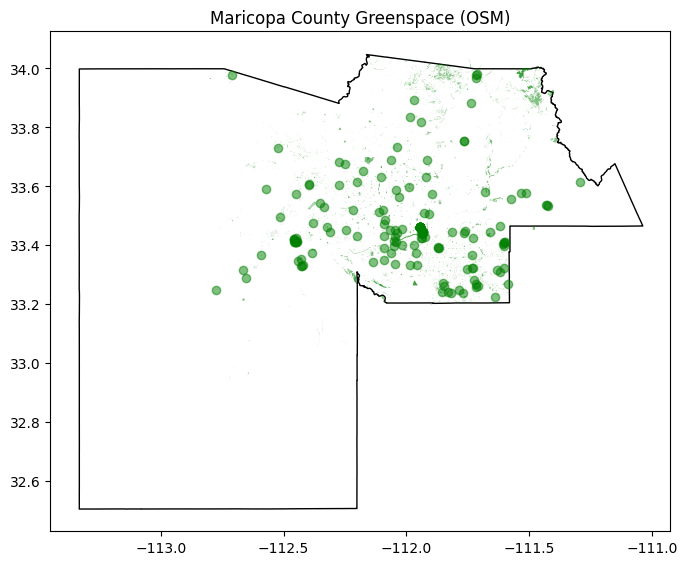

In [34]:
ax = mc.plot(color="white", edgecolor="black", figsize=(8,8))
greenspace_mc.plot(ax=ax, color="green", alpha=0.5)

plt.title("Maricopa County Greenspace (OSM)")
plt.show()

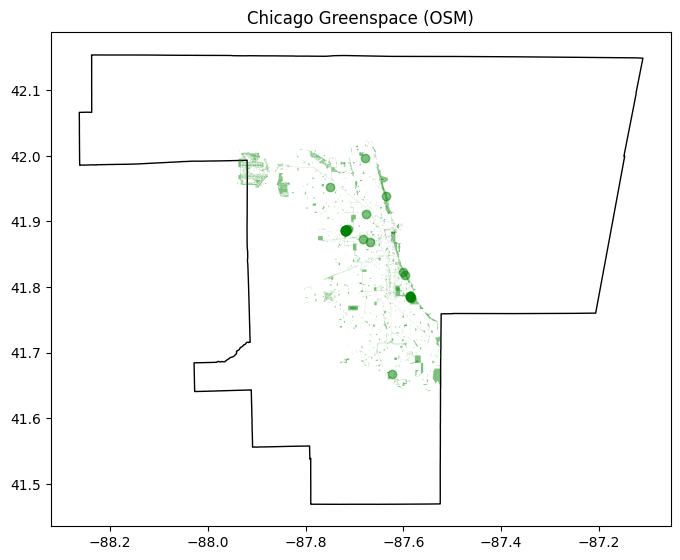

In [55]:
import matplotlib.pyplot as plt

ax = ch.plot(color="white", edgecolor="black", figsize=(8,8))
greenspace_ch.plot(ax=ax, color="green", alpha=0.5)

plt.title("Chicago Greenspace (OSM)")
plt.show()